# Reading in data

In [65]:
import scanpy as sc
import pandas as pd

# QC

In [66]:
adata = sc.read('../results/raw.008um.concat.h5ad')

Only considering the two last: ['.concat', '.h5ad'].
Only considering the two last: ['.concat', '.h5ad'].


/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [67]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS','RPL'))
adata.var['hb'] = adata.var_names.str.contains('^HB[^(P)]')

In [68]:
sc.pp.calculate_qc_metrics(adata, inplace = True, qc_vars = ['mt','ribo','hb'])
adata

AnnData object with n_obs × n_vars = 822040 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'hb'
    obsm: 'spatial'

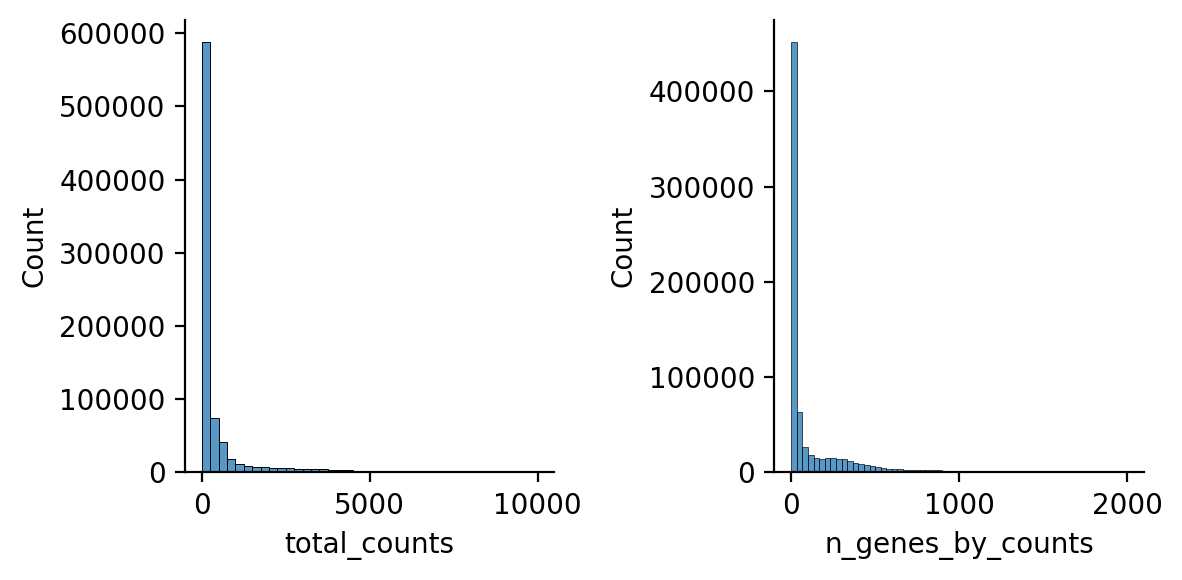

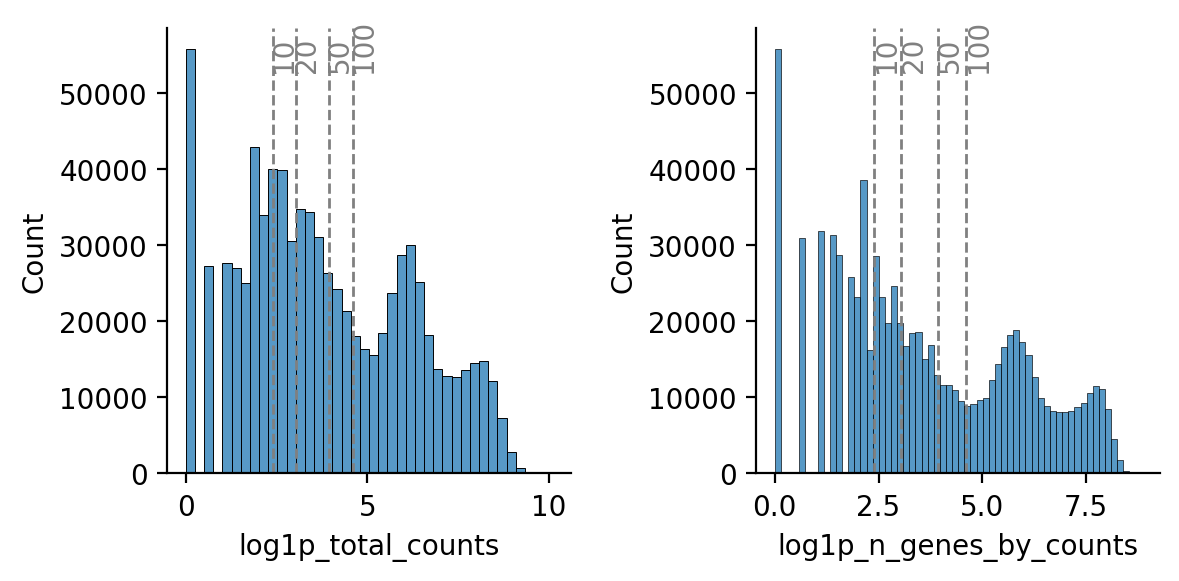

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def add_vlines(ax, positions, labels=None, color='gray', log_transform=False):
    """Add labeled vertical lines to a plot."""
    if labels is None:
        labels = [str(x) for x in positions]
    
    for i, x in enumerate(positions):
        xpos = np.log1p(x) if log_transform else x
        ax.axvline(xpos, color=color, linestyle='--', linewidth=1)
        ax.text(xpos + 0.3, ax.get_ylim()[1]*0.9, labels[i], color=color,
                rotation=90, verticalalignment='bottom', horizontalalignment = 'center')

# First row of plots (raw counts)
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)
sns.histplot(adata.obs['total_counts'][adata.obs['total_counts'] < 10000],
             kde=False, bins=40, ax=axs[0])
sns.histplot(adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts'] < 2000],
             kde=False, bins=60, ax=axs[1])
sns.despine()
plt.tight_layout()

# Second row of plots (log1p-transformed counts)
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)
sns.histplot(adata.obs['log1p_total_counts'][adata.obs['log1p_total_counts'] < 40],
             kde=False, bins=40, ax=axs[0])
add_vlines(axs[0], [10, 20, 50, 100], labels=['10', '20', '50', '100'], color='gray', log_transform=True)

sns.histplot(adata.obs['log1p_n_genes_by_counts'][adata.obs['log1p_n_genes_by_counts'] < 40],
             kde=False, bins=60, ax=axs[1])
add_vlines(axs[1], [10, 20, 50, 100], labels=['10', '20', '50', '100'], color='gray', log_transform=True)

sns.despine()
plt.tight_layout()


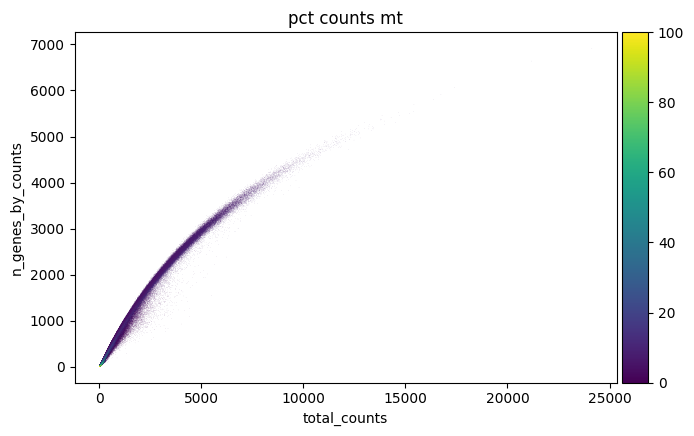

In [70]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color = "pct_counts_mt")

In [71]:
sc.pp.filter_cells(adata, min_counts = 10)
sc.pp.filter_genes(adata, min_cells = 20)

/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/homebrew/Caskroom/miniforge/base/envs/robin/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [75]:
adata


AnnData object with n_obs × n_vars = 567709 × 16194
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'hb', 'n_cells'
    obsm: 'spatial'

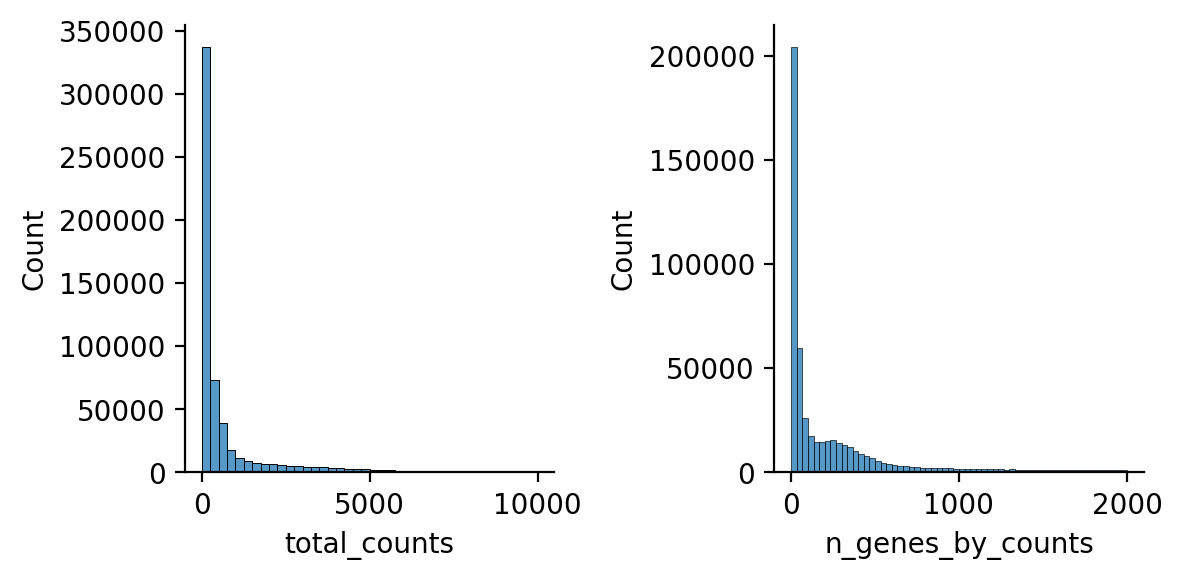

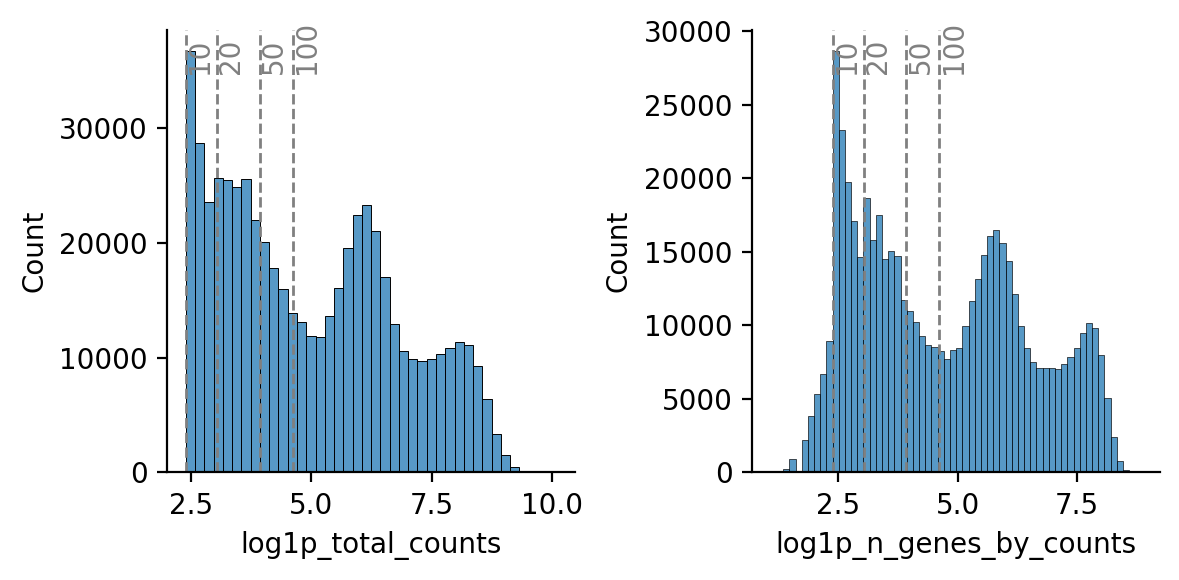

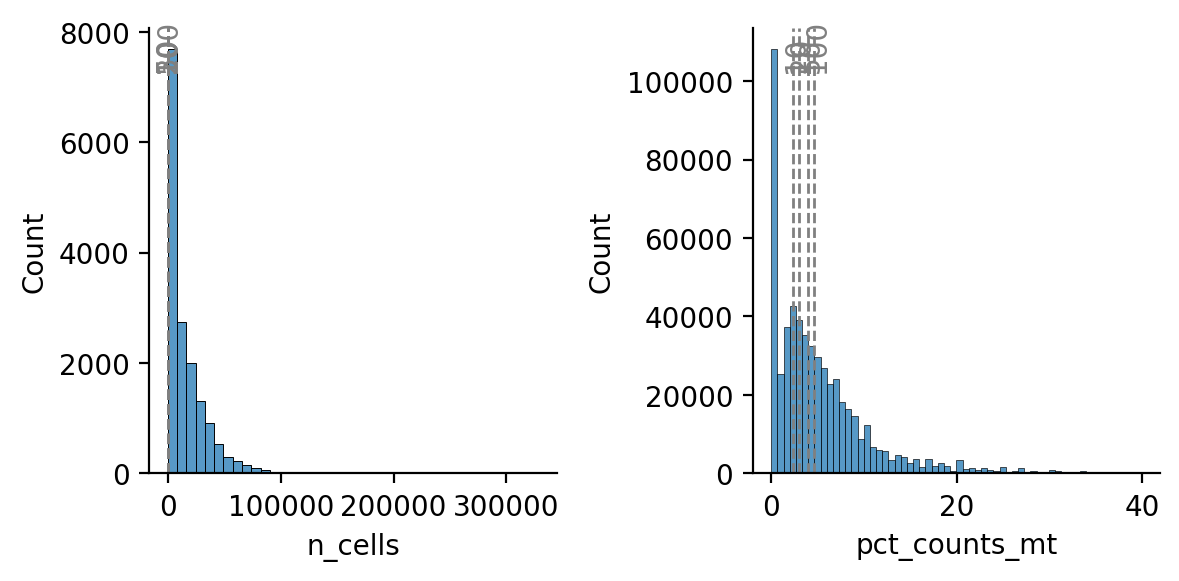

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def add_vlines(ax, positions, labels=None, color='gray', log_transform=False):
    """Add labeled vertical lines to a plot."""
    if labels is None:
        labels = [str(x) for x in positions]
    
    for i, x in enumerate(positions):
        xpos = np.log1p(x) if log_transform else x
        ax.axvline(xpos, color=color, linestyle='--', linewidth=1)
        ax.text(xpos + 0.3, ax.get_ylim()[1]*0.9, labels[i], color=color,
                rotation=90, verticalalignment='bottom', horizontalalignment = 'center')

# First row of plots (raw counts)
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)
sns.histplot(adata.obs['total_counts'][adata.obs['total_counts'] < 10000],
             kde=False, bins=40, ax=axs[0])
sns.histplot(adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts'] < 2000],
             kde=False, bins=60, ax=axs[1])
sns.despine()
plt.tight_layout()

# Second row of plots (log1p-transformed counts)
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)
sns.histplot(adata.obs['log1p_total_counts'][adata.obs['log1p_total_counts'] < 40],
             kde=False, bins=40, ax=axs[0])
add_vlines(axs[0], [10, 20, 50, 100], labels=['10', '20', '50', '100'], color='gray', log_transform=True)

sns.histplot(adata.obs['log1p_n_genes_by_counts'][adata.obs['log1p_n_genes_by_counts'] < 40],
             kde=False, bins=60, ax=axs[1])
add_vlines(axs[1], [10, 20, 50, 100], labels=['10', '20', '50', '100'], color='gray', log_transform=True)

sns.despine()
plt.tight_layout()

# Second row of plots (log1p-transformed counts)
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)
sns.histplot(adata.var['n_cells'],
             kde=False, bins=40, ax=axs[0])
add_vlines(axs[0], [10, 20, 50, 100], labels=['10', '20', '50', '100'], color='gray', log_transform=True)
sns.histplot(adata.obs['pct_counts_mt'][adata.obs['pct_counts_mt'] < 40],
             kde=False, bins=60, ax=axs[1])
add_vlines(axs[1], [10, 20, 50, 100], labels=['10', '20', '50', '100'], color='gray', log_transform=True)

sns.despine()
plt.tight_layout()


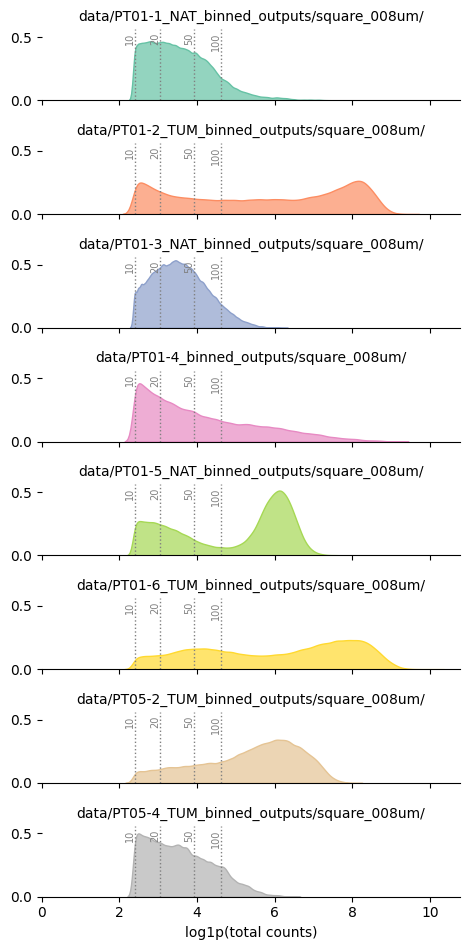

In [73]:
# Replace 'sample_id' with your actual batch key if different
df = adata.obs[['log1p_total_counts', 'batch']].copy()
df = df.rename(columns={'log1p_total_counts': 'log_counts'})

# Optional: Sort samples
df['batch'] = pd.Categorical(df['batch'], ordered=True)

# Create ridgeplot (joyplot)
g = sns.FacetGrid(
    df,
    row='batch',
    hue='batch',
    aspect=4,
    height=1.2,
    palette='Set2'
)

g.map(sns.kdeplot, 'log_counts', fill=True, alpha=0.7, bw_adjust=0.5)
g.set_titles(row_template='{row_name}')
g.set(xlim=(0, None), xlabel='log1p(total counts)', ylabel='')
g.despine(left=True)

import numpy as np

# Natural values and their log1p
raw_vals = [10, 20, 50, 100]
log_vals = [np.log1p(v) for v in raw_vals]

# Loop over all axes in the FacetGrid
for ax in g.axes.flatten():
    for lv, rv in zip(log_vals, raw_vals):
        ax.axvline(x=lv, color='gray', linestyle='dotted', linewidth=1)
        ax.text(lv, ax.get_ylim()[1]*0.95, f'{rv}', rotation=90, ha='right', va='top', fontsize=7, color='gray')


plt.tight_layout()
plt.show()

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


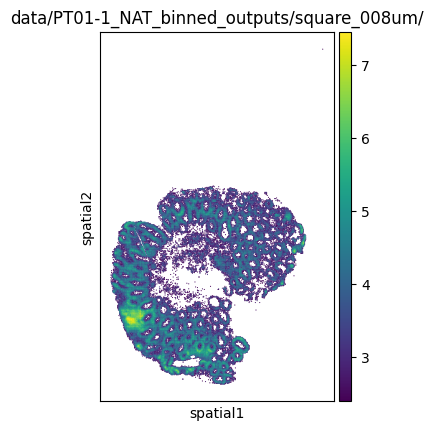

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


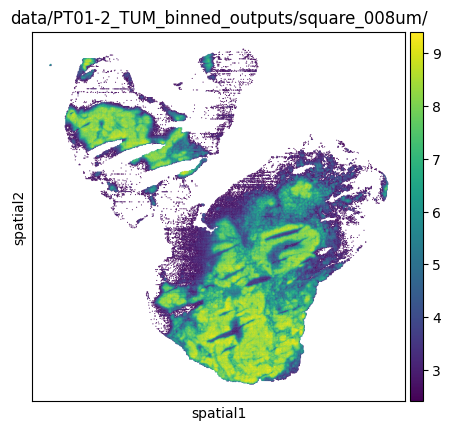

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


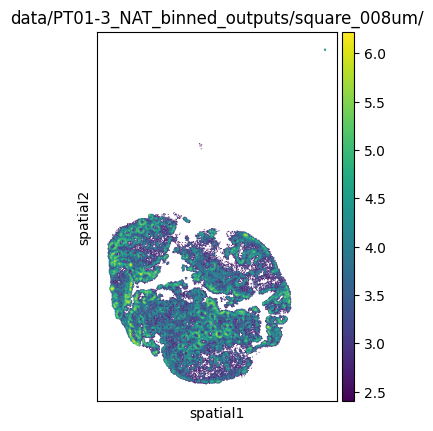

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


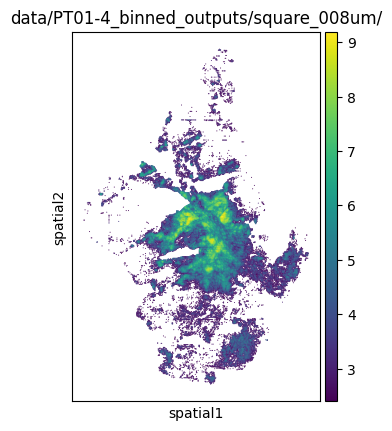

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


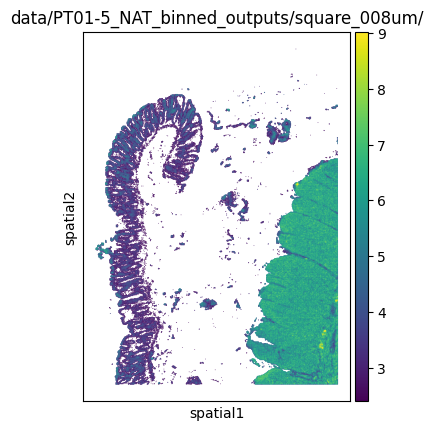

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


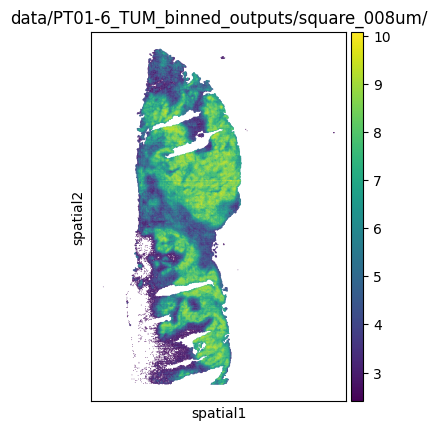

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


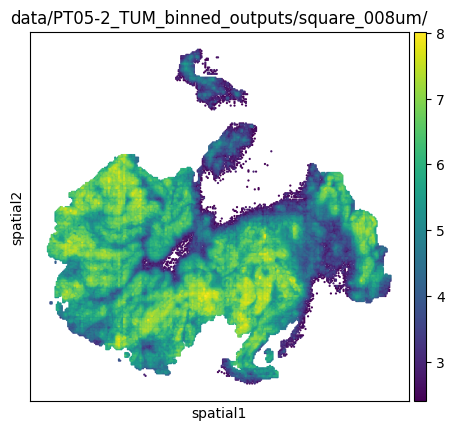

/var/folders/m3/jlzygtz56hn0n13xjz1g33380000gn/T/ipykernel_16569/2822076281.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)


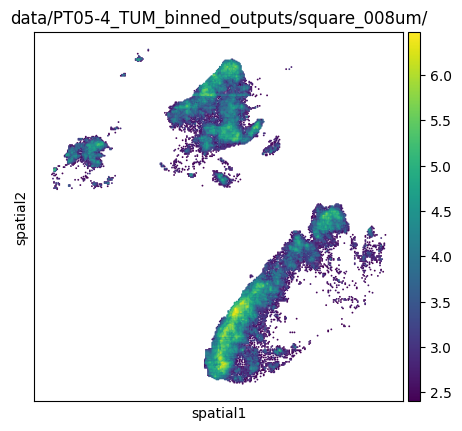

In [74]:
for path in adata.obs['batch'].unique():
    a = adata[adata.obs['batch']==path]
    sc.pl.spatial(a, color = ['log1p_total_counts'], spot_size = 3, title = path)